# Advanced Analytics + Risk Metrics — Day 6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 6)
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE = r"D:\MutualFundAnalytics\data"
PROCESSED = f"{BASE}\\processed"
RAW = f"{BASE}\\raw"

# Load data
daily_returns = pd.read_csv(f"{PROCESSED}\\daily_returns.csv", index_col=0, parse_dates=True)
fund_scorecard = pd.read_csv(f"{PROCESSED}\\fund_scorecard.csv")
transactions = pd.read_csv(f"{PROCESSED}\\08_investor_transactions_cleaned.csv", parse_dates=['transaction_date'])
portfolio = pd.read_csv(f"{RAW}\\09_portfolio_holdings.csv")
sharpe = pd.read_csv(f"{PROCESSED}\\sharpe_ratio.csv")
fund_master = pd.read_csv(f"{RAW}\\01_fund_master.csv")

print("All files loaded!")
print(f"Daily returns shape: {daily_returns.shape}")
print(f"Transactions shape: {transactions.shape}")
print(f"Fund scorecard shape: {fund_scorecard.shape}")

✅ All files loaded!
Daily returns shape: (46000, 3)
Transactions shape: (32778, 13)
Fund scorecard shape: (40, 12)


In [ ]:
print("Daily returns columns:", daily_returns.columns.tolist())
print(daily_returns.head())

Daily returns columns: ['date', 'nav', 'daily_return']
                 date       nav  daily_return
amfi_code                                    
100016     2022-01-03  520.4608           NaN
100016     2022-01-04  515.0971     -0.010306
100016     2022-01-05  521.7239      0.012865
100016     2022-01-06  515.7880     -0.011377
100016     2022-01-07  515.1639     -0.001210


In [5]:
# ── TASK 1: Historical VaR (95%) + CVaR ──────────────────────────────

results = []

for amfi_code, group in daily_returns.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    
    if len(returns) < 30:
        continue
    
    # VaR 95% = 5th percentile
    var_95 = np.percentile(returns, 5)
    
    # CVaR = mean of returns below VaR threshold
    cvar_95 = returns[returns <= var_95].mean()
    
    results.append({
        'amfi_code': amfi_code,
        'var_95_pct': round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4),
        'total_trading_days': len(returns)
    })

var_cvar_df = pd.DataFrame(results)

# Merge with fund names
var_cvar_df = var_cvar_df.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code', how='left'
)

# Sort by worst VaR
var_cvar_df = var_cvar_df.sort_values('var_95_pct')

# Save to CSV
var_cvar_df.to_csv(f"{PROCESSED}\\var_cvar_report.csv", index=False)

print("VaR + CVaR computed for", len(var_cvar_df), "funds")
print("\nTop 5 Riskiest Funds (worst VaR):")
print(var_cvar_df[['scheme_name','var_95_pct','cvar_95_pct']].head())
print("\nTop 5 Safest Funds (best VaR):")
print(var_cvar_df[['scheme_name','var_95_pct','cvar_95_pct']].tail())

VaR + CVaR computed for 40 funds

Top 5 Riskiest Funds (worst VaR):
                                       scheme_name  var_95_pct  cvar_95_pct
22       SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
17          Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
4           ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
11  Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
21      SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595

Top 5 Safest Funds (best VaR):
                                          scheme_name  var_95_pct  cvar_95_pct
13  Nippon India Gilt Securities Fund - Regular - ...     -0.3804      -0.4919
1        HDFC Short Term Debt Fund - Regular - Growth     -0.3793      -0.4994
31               Kotak Liquid Fund - Regular - Growth     -0.0285      -0.0411
5                 ABSL Liquid Fund - Regular - Growth     -0.0269      -0.0422
27           ICICI Pru Liquid Fund - Regular - Gr

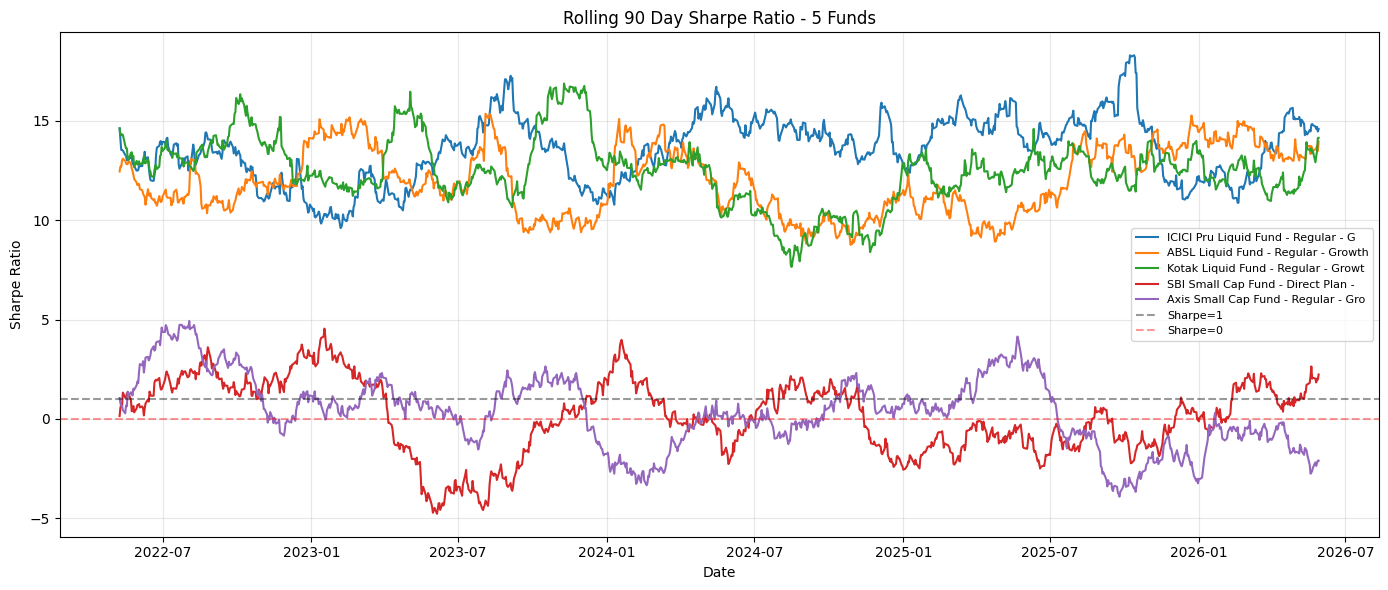

done - chart saved


In [6]:
# Task 2 - Rolling 90 day Sharpe Ratio

dr = daily_returns.reset_index()

# picking 5 funds - 3 risky ones and 2 safe ones
risky = var_cvar_df.nlargest(3, 'var_95_pct')['amfi_code'].tolist()
safe = var_cvar_df.nsmallest(2, 'var_95_pct')['amfi_code'].tolist()
my_funds = risky + safe

plt.figure(figsize=(14, 6))

for code in my_funds:
    fund_data = dr[dr['amfi_code'] == code].copy()
    fund_data = fund_data.sort_values('date')
    fund_data['date'] = pd.to_datetime(fund_data['date'])
    ret = fund_data.set_index('date')['daily_return']
    
    rolling_sharpe = (ret.rolling(90).mean() / ret.rolling(90).std()) * np.sqrt(252)
    
    fname = var_cvar_df[var_cvar_df['amfi_code'] == code]['scheme_name'].values[0][:35]
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=fname, linewidth=1.5)

plt.axhline(y=1, color='black', linestyle='--', alpha=0.4, label='Sharpe=1')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.4, label='Sharpe=0')
plt.title('Rolling 90 Day Sharpe Ratio - 5 Funds')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"D:\MutualFundAnalytics\reports\rolling_sharpe_chart.png", dpi=150)
plt.show()
print("done - chart saved")

In [7]:
# Task 3 - Investor cohort analysis

# check column names first
print(transactions.columns.tolist())
print(transactions.head(3))

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   

       state       city city_tier age_group  gender  annual_income_lakh  \
0  Telangana  Hyderabad       T30       56+  Female                77.1   
1     Punjab   Amritsar       B30     18-25    Male                 7.1   
2    Haryana  Faridabad       B30     36-45    Male                47.2   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      Mandate   Verified  


In [9]:
# Task 3 - Investor cohort analysis (fixed)

transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# first transaction year per investor
first_txn = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year

# merge cohort back
txn = transactions.merge(first_txn[['investor_id', 'cohort_year']], on='investor_id', how='left')

# basic cohort stats
cohort = txn.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    total_invested=('amount_inr', 'sum')
).reset_index()

# avg sip amount separately
sip_only = txn[txn['transaction_type'] == 'Sip']
avg_sip = sip_only.groupby('cohort_year')['amount_inr'].mean().reset_index()
avg_sip.columns = ['cohort_year', 'avg_sip_amount']

cohort = cohort.merge(avg_sip, on='cohort_year', how='left')

# top fund per cohort
top_fund = (txn.groupby(['cohort_year', 'amfi_code'])['amount_inr']
            .sum().reset_index()
            .sort_values('amount_inr', ascending=False)
            .groupby('cohort_year').first().reset_index()[['cohort_year', 'amfi_code']])

cohort = cohort.merge(top_fund, on='cohort_year', how='left')
cohort = cohort.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
cohort = cohort.rename(columns={'scheme_name': 'top_fund'})
cohort['avg_sip_amount'] = cohort['avg_sip_amount'].round(2)
cohort['total_invested'] = cohort['total_invested'].round(2)

print(cohort[['cohort_year', 'total_investors', 'total_invested', 'avg_sip_amount', 'top_fund']])
print("\ndone")

   cohort_year  total_investors  total_invested  avg_sip_amount  \
0         2024             4803      3491125187        10996.89   
1         2025              197        30455243        13505.21   

                                     top_fund  
0  UTI Nifty 50 Index Fund - Regular - Growth  
1   SBI Small Cap Fund - Direct Plan - Growth  

done


In [10]:
# Task 4 - SIP Continuity Analysis
# Investors with 6+ SIPs. Flag gap > 35 days as "at-risk"

import pandas as pd

# Filter only SIP transactions
sip_txns = transactions[transactions['transaction_type'] == 'Sip'].copy()
sip_txns['transaction_date'] = pd.to_datetime(sip_txns['transaction_date'])
sip_txns = sip_txns.sort_values(['investor_id', 'transaction_date'])

# Keep only investors with 6+ SIP transactions
sip_count = sip_txns.groupby('investor_id')['transaction_date'].count()
active_investors = sip_count[sip_count >= 6].index
sip_filtered = sip_txns[sip_txns['investor_id'].isin(active_investors)]

# Calculate average gap between SIP dates per investor
def avg_gap(dates):
    dates = sorted(dates)
    if len(dates) < 2:
        return None
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return sum(gaps) / len(gaps)

gap_df = sip_filtered.groupby('investor_id')['transaction_date'].apply(avg_gap).reset_index()
gap_df.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors
gap_df['status'] = gap_df['avg_gap_days'].apply(
    lambda x: 'at-risk' if x > 35 else 'regular'
)

# Summary
total = len(gap_df)
at_risk = len(gap_df[gap_df['status'] == 'at-risk'])
regular = len(gap_df[gap_df['status'] == 'regular'])

print(f"Total investors with 6+ SIPs : {total}")
print(f"At-risk investors (gap > 35d): {at_risk}")
print(f"Regular investors            : {regular}")
print(f"\nSample at-risk investors:")
print(gap_df[gap_df['status'] == 'at-risk'].head(10))

print("\ndone")

Total investors with 6+ SIPs : 1362
At-risk investors (gap > 35d): 1332
Regular investors            : 30

Sample at-risk investors:
  investor_id  avg_gap_days   status
0   INV000004     85.400000  at-risk
1   INV000008     70.400000  at-risk
2   INV000010     64.800000  at-risk
3   INV000011     40.166667  at-risk
4   INV000012     57.000000  at-risk
5   INV000013     55.333333  at-risk
6   INV000014     75.333333  at-risk
7   INV000023     58.571429  at-risk
8   INV000028     93.600000  at-risk
9   INV000029     60.666667  at-risk

done


In [19]:
import os
print(os.getcwd())

d:\MutualFundAnalytics\notebooks


In [21]:
import os
os.chdir(r'D:\MutualFundAnalytics')
print(os.getcwd())

D:\MutualFundAnalytics


In [22]:
nav = pd.read_csv('data/processed/02_nav_history_cleaned.csv')
print(nav.columns.tolist())
print(nav.head(3))

['amfi_code', 'date', 'nav']
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239


In [23]:
print(nav.columns.tolist())
print(nav.head(3))

['amfi_code', 'date', 'nav']
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239


In [25]:
fund_master = pd.read_csv('data/raw/01_fund_master.csv')
print(fund_master.columns.tolist())
print(fund_master.head(3))

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
   amfi_code       fund_house                                 scheme_name  \
0     119551  SBI Mutual Fund   SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund    SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund  SBI Small Cap Fund - Regular Plan - Growth   

  category sub_category     plan launch_date             benchmark  \
0   Equity    Large Cap  Regular  2006-02-14         NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01         NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09  BSE 250 SmallCap TRI   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \
0               1.54            1.0             500                1000   
1               0.66

In [26]:
# generate sharpe_ratio.csv with correct columns

nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

sharpe = (
    nav.groupby('amfi_code')['daily_return']
    .apply(lambda x: (x.mean() / x.std()) * (252 ** 0.5) if x.std() > 0 else 0)
    .reset_index()
)
sharpe.columns = ['amfi_code', 'sharpe_ratio']

sharpe = sharpe.merge(
    fund_master[['amfi_code', 'scheme_name', 'category', 'risk_category']],
    on='amfi_code', how='left'
)

sharpe['sharpe_ratio'] = sharpe['sharpe_ratio'].round(4)
sharpe.to_csv('data/processed/sharpe_ratio.csv', index=False)

print(f"Done — {len(sharpe)} funds")
print(sharpe.head())

Done — 40 funds
   amfi_code  sharpe_ratio                                        scheme_name  \
0     100016        0.2453          HDFC Top 100 Fund - Regular Plan - Growth   
1     100025        1.0973       HDFC Short Term Debt Fund - Regular - Growth   
2     100033        1.4369  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3     101206        1.4734      ABSL Frontline Equity Fund - Regular - Growth   
4     101207        0.4146             ABSL Small Cap Fund - Regular - Growth   

  category risk_category  
0   Equity      Moderate  
1     Debt           Low  
2   Equity          High  
3   Equity      Moderate  
4   Equity     Very High  


In [27]:
# Task 5 - Simple Fund Recommender

sharpe_df = pd.read_csv('data/processed/sharpe_ratio.csv')

# risk_category values are: Low, Moderate, High, Very High
risk_map = {
    'Low':      ['Low'],
    'Moderate': ['Moderate'],
    'High':     ['High', 'Very High']
}

def recommend_funds(risk_level, top_n=3):
    risk_level = risk_level.strip().title()
    if risk_level not in risk_map:
        print("Invalid input. Use Low / Moderate / High")
        return None
    
    categories = risk_map[risk_level]
    filtered = sharpe_df[sharpe_df['risk_category'].isin(categories)].copy()
    
    if filtered.empty:
        print(f"No funds found for {risk_level}")
        return None
    
    top = filtered.nlargest(top_n, 'sharpe_ratio')[['scheme_name', 'risk_category', 'sharpe_ratio']]
    top = top.reset_index(drop=True)
    top.index += 1
    
    print(f"\n{'='*55}")
    print(f"  Top {top_n} Funds — {risk_level} Risk")
    print(f"{'='*55}")
    print(top.to_string())
    print(f"{'='*55}\n")
    return top

recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


  Top 3 Funds — Low Risk
                                scheme_name risk_category  sharpe_ratio
1  ICICI Pru Liquid Fund - Regular - Growth           Low       13.6559
2      Kotak Liquid Fund - Regular - Growth           Low       12.5740
3       ABSL Liquid Fund - Regular - Growth           Low       12.0192


  Top 3 Funds — Moderate Risk
                                      scheme_name risk_category  sharpe_ratio
1   Mirae Asset Large Cap Fund - Regular - Growth      Moderate        1.9062
2       SBI Bluechip Fund - Regular Plan - Growth      Moderate        1.6813
3  Nippon India Large Cap Fund - Regular - Growth      Moderate        1.5411


  Top 3 Funds — High Risk
                                     scheme_name risk_category  sharpe_ratio
1  Mirae Asset Tax Saver Fund - Regular - Growth          High        1.6027
2       ICICI Pru Midcap Fund - Regular - Growth          High        1.5170
3             DSP Midcap Fund - Regular - Growth          High        1.4984



,scheme_name,risk_category,sharpe_ratio
1,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.6027
2,ICICI Pru Midcap Fund - Regular - Growth,High,1.5170
3,DSP Midcap Fund - Regular - Growth,High,1.4984


In [28]:
script = '''import pandas as pd

sharpe_df = pd.read_csv('data/processed/sharpe_ratio.csv')

risk_map = {
    'Low':      ['Low'],
    'Moderate': ['Moderate'],
    'High':     ['High', 'Very High']
}

def recommend_funds(risk_level, top_n=3):
    risk_level = risk_level.strip().title()
    if risk_level not in risk_map:
        print("Invalid input. Use Low / Moderate / High")
        return
    categories = risk_map[risk_level]
    filtered = sharpe_df[sharpe_df['risk_category'].isin(categories)]
    top = filtered.nlargest(top_n, 'sharpe_ratio')[['scheme_name', 'risk_category', 'sharpe_ratio']]
    print(f"\\nTop {top_n} funds — {risk_level} risk:")
    print(top.to_string(index=False))
    return top

if __name__ == '__main__':
    risk = input("Enter risk level (Low/Moderate/High): ").strip()
    recommend_funds(risk)
'''

with open('recommender.py', 'w') as f:
    f.write(script)

print("recommender.py saved.")

recommender.py saved.


In [31]:
# Task 6 - Sector HHI Concentration

holdings = pd.read_csv('data/raw/09_portfolio_holdings.csv')
fund_master = pd.read_csv('data/raw/01_fund_master.csv')

# weight_pct is already in percentage, convert to decimal
holdings['weight_decimal'] = holdings['weight_pct'] / 100
holdings['weight_sq'] = holdings['weight_decimal'] ** 2

# HHI per fund = sum of squared weights
hhi = holdings.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi.columns = ['amfi_code', 'hhi_score']
hhi['hhi_score'] = hhi['hhi_score'].round(4)

# merge fund info
hhi = hhi.merge(
    fund_master[['amfi_code', 'scheme_name', 'category', 'risk_category']],
    on='amfi_code', how='left'
)

# check what categories exist
print("Categories in data:")
print(hhi['category'].value_counts())

Categories in data:
category
Equity    34
Name: count, dtype: int64


In [32]:
# all 34 funds are Equity — no filter needed, just sort and display

equity_hhi = hhi[hhi['category'] == 'Equity'].copy()
equity_hhi = equity_hhi.sort_values('hhi_score', ascending=False).reset_index(drop=True)

print(f"Total equity funds analysed: {len(equity_hhi)}")

print("\nMost Concentrated Funds (High HHI):")
print(equity_hhi[['scheme_name', 'risk_category', 'hhi_score']].head(10).to_string(index=False))

print("\nMost Diversified Funds (Low HHI):")
print(equity_hhi[['scheme_name', 'risk_category', 'hhi_score']].tail(10).to_string(index=False))

print("\nHHI Stats:")
print(equity_hhi['hhi_score'].describe().round(4))

# flag concentrated funds — HHI > 0.15 is considere

Total equity funds analysed: 34

Most Concentrated Funds (High HHI):
                                          scheme_name   risk_category  hhi_score
                Axis Bluechip Fund - Regular - Growth        Moderate     0.2064
               ABSL Small Cap Fund - Regular - Growth       Very High     0.2007
            SBI Small Cap Fund - Direct Plan - Growth       Very High     0.1748
           UTI Nifty 50 Index Fund - Regular - Growth        Moderate     0.1747
       Nippon India Large Cap Fund - Regular - Growth        Moderate     0.1683
Mirae Asset Emerging Bluechip Fund - Regular - Growth Moderately High     0.1679
             ICICI Pru Midcap Fund - Regular - Growth            High     0.1576
    ICICI Pru Value Discovery Fund - Regular - Growth Moderately High     0.1538
    HDFC Mid-Cap Opportunities Fund - Direct - Growth            High     0.1524
               Kotak Bluechip Fund - Regular - Growth        Moderate     0.1497

Most Diversified Funds (Low HHI):
     

### 5 Key Insights from Mutual Fund Data

In [33]:
# Insight 1 - Funds with Highest VaR (Most Risky)

var_report = pd.read_csv('data/processed/var_cvar_report.csv')
print(var_report.columns.tolist())

['amfi_code', 'var_95_pct', 'cvar_95_pct', 'total_trading_days', 'scheme_name']


In [36]:
# Insight 1 - Funds with Highest VaR (Most Risky)

top_var = var_report.sort_values('var_95_pct').head(5)

print("Funds with Highest Risk (Worst VaR at 95%):")
print(top_var[['scheme_name', 'var_95_pct', 'cvar_95_pct']].to_string(index=False))

Funds with Highest Risk (Worst VaR at 95%):
                                   scheme_name  var_95_pct  cvar_95_pct
     SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
        Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
        ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
    SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595


In [37]:
# Insight 2 - Investor Cohort Behaviour

print("Investor Cohort Summary:")
print(cohort[['cohort_year', 'total_investors', 'total_invested', 'avg_sip_amount', 'top_fund']].to_string(index=False))

Investor Cohort Summary:
 cohort_year  total_investors  total_invested  avg_sip_amount                                   top_fund
        2024             4803      3491125187        10996.89 UTI Nifty 50 Index Fund - Regular - Growth
        2025              197        30455243        13505.21  SBI Small Cap Fund - Direct Plan - Growth


In [39]:
# Insight 3 - SIP Continuity Rate

transactions = pd.read_csv('data/processed/08_investor_transactions_cleaned.csv')
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

sip_txns = transactions[transactions['transaction_type'] == 'Sip'].copy()
sip_txns = sip_txns.sort_values(['investor_id', 'transaction_date'])

investor_sip_counts = sip_txns.groupby('investor_id')['transaction_date'].count()
active_investors = investor_sip_counts[investor_sip_counts >= 6].index
sip_active = sip_txns[sip_txns['investor_id'].isin(active_investors)].copy()

sip_active['prev_date'] = sip_active.groupby('investor_id')['transaction_date'].shift(1)
sip_active['gap_days'] = (sip_active['transaction_date'] - sip_active['prev_date']).dt.days

gap_summary = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
gap_summary.columns = ['investor_id', 'avg_gap_days']
gap_summary['status'] = gap_summary['avg_gap_days'].apply(
    lambda x: 'at-risk' if x > 35 else 'regular'
)

continuity_rate = (gap_summary['status'] == 'regular').mean() * 100
at_risk_count = (gap_summary['status'] == 'at-risk').sum()
regular_count = (gap_summary['status'] == 'regular').sum()

print(f"SIP Continuity Rate : {continuity_rate:.1f}%")
print(f"Regular investors   : {regular_count}")
print(f"At-risk investors   : {at_risk_count}")
print(f"At-risk = avg gap between SIPs exceeds 35 days")

SIP Continuity Rate : 2.2%
Regular investors   : 30
At-risk investors   : 1332
At-risk = avg gap between SIPs exceeds 35 days


In [41]:
# Insight 4 - Sector Concentration (HHI)

holdings = pd.read_csv('data/raw/09_portfolio_holdings.csv')
fund_master = pd.read_csv('data/raw/01_fund_master.csv')

holdings['weight_decimal'] = holdings['weight_pct'] / 100
holdings['weight_sq'] = holdings['weight_decimal'] ** 2

hhi = holdings.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi.columns = ['amfi_code', 'hhi_score']
hhi['hhi_score'] = hhi['hhi_score'].round(4)

hhi = hhi.merge(
    fund_master[['amfi_code', 'scheme_name', 'category', 'risk_category']],
    on='amfi_code', how='left'
)

equity_hhi = hhi[hhi['category'] == 'Equity'].copy()
equity_hhi['concentration_flag'] = equity_hhi['hhi_score'].apply(
    lambda x: 'Concentrated' if x > 0.15 else 'Diversified'
)
equity_hhi = equity_hhi.sort_values('hhi_score', ascending=False).reset_index(drop=True)

print("Most Concentrated Equity Funds:")
print(equity_hhi[['scheme_name', 'hhi_score', 'concentration_flag']].head(5).to_string(index=False))

print("\nMost Diversified Equity Funds:")
print(equity_hhi[['scheme_name', 'hhi_score', 'concentration_flag']].tail(5).to_string(index=False))

Most Concentrated Equity Funds:
                                   scheme_name  hhi_score concentration_flag
         Axis Bluechip Fund - Regular - Growth     0.2064       Concentrated
        ABSL Small Cap Fund - Regular - Growth     0.2007       Concentrated
     SBI Small Cap Fund - Direct Plan - Growth     0.1748       Concentrated
    UTI Nifty 50 Index Fund - Regular - Growth     0.1747       Concentrated
Nippon India Large Cap Fund - Regular - Growth     0.1683       Concentrated

Most Diversified Equity Funds:
                                   scheme_name  hhi_score concentration_flag
        Axis Small Cap Fund - Regular - Growth     0.1096        Diversified
     ICICI Pru Bluechip Fund - Direct - Growth     0.1087        Diversified
Nippon India Small Cap Fund - Regular - Growth     0.1084        Diversified
      SBI Bluechip Fund - Direct Plan - Growth     0.1080        Diversified
    SBI Small Cap Fund - Regular Plan - Growth     0.1073        Diversified


In [42]:
# Insight 5 - Risk-Adjusted Performance (Sharpe)

top_sharpe = sharpe_df.nlargest(5, 'sharpe_ratio')[['scheme_name', 'risk_category', 'sharpe_ratio']]
bottom_sharpe = sharpe_df.nsmallest(5, 'sharpe_ratio')[['scheme_name', 'risk_category', 'sharpe_ratio']]

print("Top 5 Funds by Sharpe Ratio:")
print(top_sharpe.to_string(index=False))

print("\nBottom 5 Funds by Sharpe Ratio:")
print(bottom_sharpe.to_string(index=False))

Top 5 Funds by Sharpe Ratio:
                                  scheme_name   risk_category  sharpe_ratio
     ICICI Pru Liquid Fund - Regular - Growth             Low       13.6559
         Kotak Liquid Fund - Regular - Growth             Low       12.5740
          ABSL Liquid Fund - Regular - Growth             Low       12.0192
Mirae Asset Large Cap Fund - Regular - Growth        Moderate        1.9062
       Kotak Flexicap Fund - Regular - Growth Moderately High        1.7159

Bottom 5 Funds by Sharpe Ratio:
                              scheme_name risk_category  sharpe_ratio
      UTI Mid Cap Fund - Regular - Growth          High        0.1526
   Axis Small Cap Fund - Regular - Growth     Very High        0.1833
SBI Small Cap Fund - Direct Plan - Growth     Very High        0.2033
HDFC Top 100 Fund - Regular Plan - Growth      Moderate        0.2453
   ABSL Small Cap Fund - Regular - Growth     Very High        0.4146
